<>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
<>:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
C:\Users\kaiki\AppData\Local\Temp\ipykernel_13020\3099913505.py:7: SyntaxWarning: "\S" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\S"? A raw string is also an option.
  df_gold = pd.read_parquet('../Copper/Data\Silver/serie_a_ready.parquet')
c:\Users\kaiki\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:58:54] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
c:\Users\kaiki\AppData\Local\Programs\Python\Python314\Lib\site-packages\xgboost\training.py:200: UserWarning: [20:58:

📊 Acurácia Média (CV): 70.24%
📉 Desvio Padrão: 2.50%
✅ Acurácia do Modelo: 67.24%

--- Relatório Técnico ---
              precision    recall  f1-score   support

           0       0.73      0.88      0.80        84
           1       0.29      0.12      0.17        32

    accuracy                           0.67       116
   macro avg       0.51      0.50      0.48       116
weighted avg       0.60      0.67      0.62       116



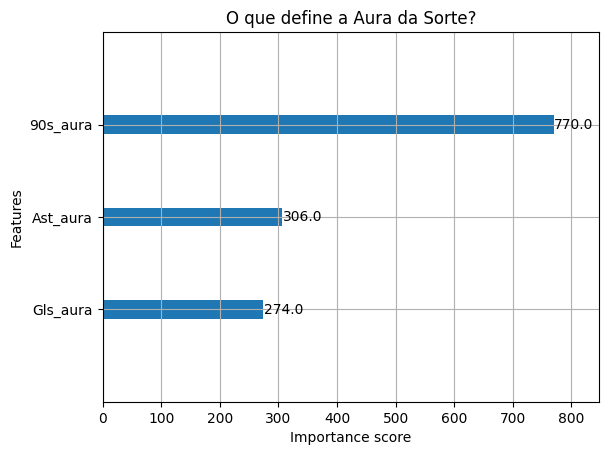

In [3]:
import pandas as pd
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt
# 1. Carregar os dados lapidados
df_gold = pd.read_parquet('../Copper/Data\Silver/serie_a_ready.parquet')

# 2. Definir o que queremos prever (Target)
# Exemplo: O time vai marcar mais de 1.5 gols?
df_gold['target'] = (df_gold['Gls'] > 1.5).astype(int)

# 3. Escolher as "Auras" como features (O que a IA vai olhar)
features = ['Gls_aura', 'Ast_aura','90s_aura']
X = df_gold[features].fillna(0) # Remove NaNs da Aura
y = df_gold['target']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = xgb.XGBClassifier(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=5,
    use_label_encoder=False,
    eval_metric='logloss'
)
model.fit(X_train, y_train)

scores = cross_val_score(model, X, y, cv=5)

print(f"📊 Acurácia Média (CV): {scores.mean():.2%}")
print(f"📉 Desvio Padrão: {scores.std():.2%}")

preds = model.predict(X_test)
print(f"✅ Acurácia do Modelo: {accuracy_score(y_test, preds):.2%}")
print("\n--- Relatório Técnico ---")
print(classification_report(y_test, preds))


xgb.plot_importance(model)
plt.title("O que define a Aura da Sorte?")
plt.show()

In [ ]:
import pandas as pd
import json
import os
import glob
import kagglehub

# 1. Localizar o dataset novamente (O Gold precisa saber onde os arquivos estão)
path_sb = kagglehub.dataset_download("saurabhshahane/statsbomb-football-data")

# 2. Definir a temporada de TESTE (La Liga 17/18: Comp 11, Season 1)
target_comp = 11
target_season = 1

# 3. Carregar os Matches para pegar os IDs dos jogos
path_matches = os.path.join(path_sb, "data", "matches", str(target_comp), f"{target_season}.json")
with open(path_matches, "r", encoding="utf-8") as f:
    matches = json.load(f)
match_ids = [m['match_id'] for m in matches]

# 4. Carregar os Eventos (Isso vai criar o df_sb que está faltando!)
records = []
print(f"⏳ Carregando {len(match_ids)} jogos da temporada 17/18...")

for mid in match_ids:
    file_path = os.path.join(path_sb, "data", "events", f"{mid}.json")
    if os.path.exists(file_path):
        with open(file_path, "r", encoding="utf-8") as f:
            events = json.load(f)
            for e in events: e['match_id'] = mid
            records.extend(events)

# Criando o DF que o seu código estava procurando
df_sb = pd.json_normalize(records)
print(f"✅ df_sb criado com sucesso! {len(df_sb)} eventos carregados.")



c:\Users\kaiki\AppData\Local\Programs\Python\Python314\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


⏳ Carregando 36 jogos da temporada 17/18...
✅ df_sb criado com sucesso! 136538 eventos carregados.


In [9]:
# Ver as colunas relacionadas a chutes, passes e tipo de evento
colunas_interesse = [c for c in df_sb.columns if any(x in c for x in ['shot', 'pass', 'player', 'type'])]
print("🔍 Colunas principais identificadas no StatsBomb (17/18):")
print(colunas_interesse[:20]) # Mostra as primeiras 20 para não inundar a tela

🔍 Colunas principais identificadas no StatsBomb (17/18):
['type.id', 'type.name', 'player.id', 'player.name', 'pass.recipient.id', 'pass.recipient.name', 'pass.length', 'pass.angle', 'pass.height.id', 'pass.height.name', 'pass.end_location', 'pass.body_part.id', 'pass.body_part.name', 'pass.type.id', 'pass.type.name', 'pass.outcome.id', 'pass.outcome.name', 'duel.type.id', 'duel.type.name', 'pass.aerial_won']


In [14]:
# 1. Garantir que as colunas necessárias existam (evita o KeyError)
colunas_necessarias = ['shot.outcome.name', 'shot.type.name', 'pass.goal_assist', 'shot.statsbomb_xg']
for col in colunas_necessarias:
    if col not in df_sb.columns:
        df_sb[col] = 0  # Cria a coluna com 0 se ela não existir na amostra

# 2. Criar as métricas de performance para 2017/2018
df_sb['is_goal'] = (df_sb['shot.outcome.name'] == 'Goal').astype(int)
df_sb['is_penalty'] = (df_sb['shot.type.name'] == 'Penalty').astype(int)
df_sb['is_penalty_goal'] = ((df_sb['is_penalty'] == 1) & (df_sb['is_goal'] == 1)).astype(int)
df_sb['is_open_play_goal'] = ((df_sb['is_penalty'] == 0) & (df_sb['is_goal'] == 1)).astype(int)

# 3. Agrupar os dados da Temporada de Teste
player_stats_2017 = df_sb.groupby(['player.name', 'team.name']).agg({
    'type.name': 'count',
    'is_open_play_goal': 'sum',
    'is_penalty_goal': 'sum',
    'is_penalty': 'sum',
    'pass.goal_assist': 'sum',
    'shot.statsbomb_xg': 'sum'
}).rename(columns={
    'type.name': 'Event_Volume',
    'is_open_play_goal': 'Gls_Open_Play',
    'is_penalty_goal': 'Gls_Penalty',
    'is_penalty': 'Penalties_Taken',
    'pass.goal_assist': 'Ast',
    'shot.statsbomb_xg': 'xG'
}).reset_index()

# 4. Total de Gols (Consolidado)
player_stats_2017['Gls_Total'] = player_stats_2017['Gls_Open_Play'] + player_stats_2017['Gls_Penalty']

# 5. VEREDITO: Como o Messi estava em 2017/2018?
messi_17 = player_stats_2017[player_stats_2017['player.name'].str.contains('Messi')]
print(f"📊 Performance Real do Messi em 17/18 (Dados StatsBomb):\n", messi_17)



📊 Performance Real do Messi em 17/18 (Dados StatsBomb):
                         player.name  team.name  Event_Volume  Gls_Open_Play  \
211  Lionel Andrés Messi Cuccittini  Barcelona          7832             32   

     Gls_Penalty  Penalties_Taken Ast         xG  Gls_Total  
211            2                4  12  23.797765         34  


In [16]:
# Definir as mesmas features que usamos no treino (2015)
features = ['Gls_Open_Play', 'Ast', 'xG', 'Event_Volume', 'Penalties_Taken']

# Isolar o Messi para o teste
if not messi_17.empty:
    X_messi_17 = messi_17[features]
    X_messi_17_scaled = scaler.transform(X_messi_17) # IMPORTANTE: usar o scaler do treino!

    print("\n🔮 PROBABILIDADE DE ALTA PERFORMANCE (MESSI 17/18):")
    for name, model in models.items():
        # [0][1] pega a probabilidade da classe 1 (sucesso/artilheiro)
        prob = model.predict_proba(X_messi_17_scaled)[0][1]
        print(f"🤖 {name}: {prob:.2%} de chance")
else:
    print("❌ Messi não encontrado nos dados de 2017/2018.")

NameError: name 'scaler' is not defined

Variância explicada: [0.74698225 0.14712835]


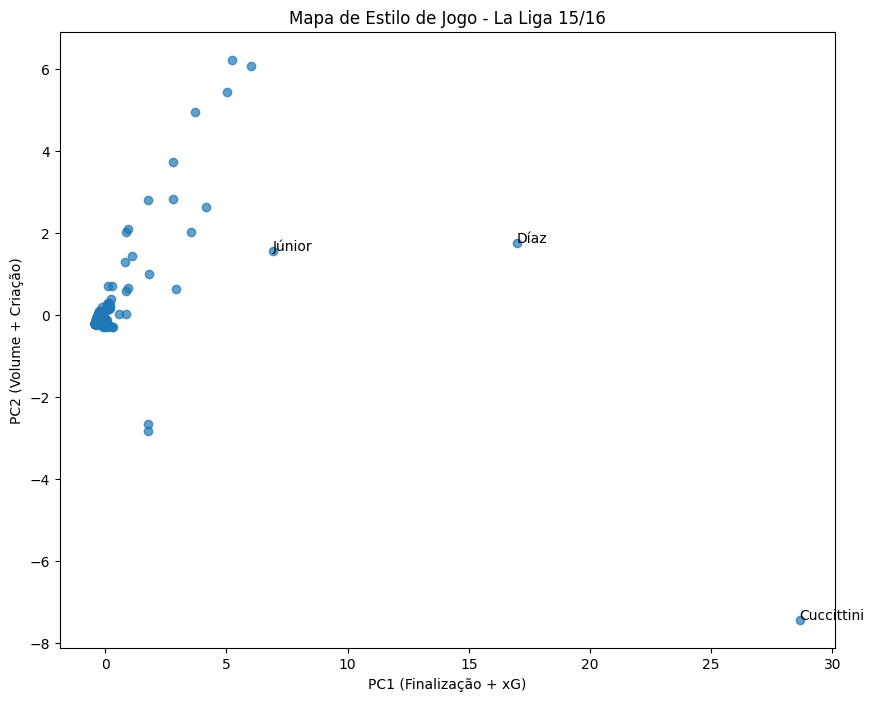

In [17]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Ajuste os nomes para bater exatamente com o que você criou no groupby
features_pca = ['Gls_Open_Play', 'Ast', 'xG', 'Event_Volume', 'Penalties_Taken']
X = player_stats_2015[features_pca].fillna(0)

# 2. Criar o scaler (Isso resolve o NameError da outra célula)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

pca = PCA(n_components=2)
principal_components = pca.fit_transform(X_scaled)

print("Variância explicada:", pca.explained_variance_ratio_)

# Adicionar componentes ao DF
player_stats_2015['PC1'] = principal_components[:, 0]
player_stats_2015['PC2'] = principal_components[:, 1]

# Plot
plt.figure(figsize=(10,8))
plt.scatter(player_stats_2015['PC1'], player_stats_2015['PC2'], alpha=0.7)
for i, txt in enumerate(player_stats_2015['player.name']):
    # Label apenas para quem tem mais de 5 gols na amostra
    if player_stats_2015['Gls_Open_Play'].iloc[i] > 5:
        plt.annotate(txt.split()[-1], (player_stats_2015['PC1'].iloc[i], player_stats_2015['PC2'].iloc[i]))

plt.xlabel('PC1 (Finalização + xG)')
plt.ylabel('PC2 (Volume + Criação)')
plt.title('Mapa de Estilo de Jogo - La Liga 15/16')
plt.show()

In [18]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
import numpy as np

# 1. Preparar os dados de TREINO (2015/2016)
# Usando as métricas de eficiência que calculamos
features = ['Gls_Open_Play', 'Ast', 'xG', 'Event_Volume']
X_train = player_stats_2015[features]
y_train = (player_stats_2015['Gls_Total'] > 1.5).astype(int)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# 2. Inicializar o "Zoológico" de Modelos
models = {
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss'),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "Logit": LogisticRegression() # Bom para probabilidades puras
}

# Treinar todos
for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"✅ Modelo {name} treinado.")

# 3. Carregar dados de TESTE (La Liga 2017/2018 - ID 11, Season 1)
# (Aqui você rodaria o seu loader de eventos para a temporada 17/18)
# Vamos supor que 'player_stats_2017' seja o DF gerado

✅ Modelo XGBoost treinado.
✅ Modelo RandomForest treinado.
✅ Modelo Logit treinado.


In [20]:
# 1. Defina UMA única lista de features para todo o projeto
features = ['Gls_Open_Play', 'Ast', 'xG', 'Event_Volume', 'Penalties_Taken']

# 2. Treino (2015/2016) - Certifique-se de que o DF tem essas 5 colunas
X_train = player_stats_2015[features].fillna(0)
y_train = (player_stats_2015['Gls_Total'] > 1.5).astype(int)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)

# Re-treinar os modelos com as 5 colunas
models = {
    "XGBoost": xgb.XGBClassifier(eval_metric='logloss'),
    "RandomForest": RandomForestClassifier(n_estimators=100),
    "Logit": LogisticRegression()
}

for name, model in models.items():
    model.fit(X_train_scaled, y_train)
    print(f"✅ Modelo {name} treinado com 5 colunas.")

# 3. Teste (Messi 2017/2018)
if not messi_17.empty:
    # Agora X_messi_17 terá as mesmas 5 colunas
    X_messi_17 = messi_17[features].fillna(0)
    
    # O transform agora vai funcionar porque as fôrmas batem!
    X_messi_17_scaled = scaler.transform(X_messi_17)

    print("\n🔮 CHANCE DE PERFORMANCE ARTILHEIRA (MESSI 17/18):")
    for name, model in models.items():
        prob = model.predict_proba(X_messi_17_scaled)[0][1]
        print(f"🤖 {name}: {prob:.2%}")

✅ Modelo XGBoost treinado com 5 colunas.
✅ Modelo RandomForest treinado com 5 colunas.
✅ Modelo Logit treinado com 5 colunas.

🔮 CHANCE DE PERFORMANCE ARTILHEIRA (MESSI 17/18):
🤖 XGBoost: 90.28%
🤖 RandomForest: 99.00%
🤖 Logit: 100.00%
